# Contrastive ResNet18 Training for CUFSF / ColorFERET Retrieval

This notebook fine-tunes a ResNet18 image encoder for sketch-to-photo retrieval.

Main run:

```text
query sketch -> encode sketch -> rank photo gallery -> evaluate correct identity rank
```

It uses the same processed CUFSF/ColorFERET-style pairs as the baseline notebook:

```text
/home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/cufsf_224_gray/pairs.csv
```

The notebook also includes optional out-of-distribution evaluation on FS2K by pairing the raw FS2K `photo*` folders with the matching `sketch*` folders.

## 1. Imports and configuration

Run this cell first. The defaults are intentionally conservative so the first training run is not painfully long.

In [1]:
from pathlib import Path
import os
import json
import math
import random
import re
import time

import numpy as np
import pandas as pd
from PIL import Image

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'matplotlib'))

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

PROJECT_ROOT = Path('/home/tndor/Documents/Work/Classwork/semester-4/main-challenge')
DATA_ROOT = PROJECT_ROOT / 'data'
CUFSF_DIR = DATA_ROOT / 'processed' / 'cufsf_224_gray'
CUFSF_PAIRS_CSV = CUFSF_DIR / 'pairs.csv'
FS2K_DIR = DATA_ROOT / 'FS2K'

OUTPUT_DIR = DATA_ROOT / 'outputs' / 'contrastive_resnet18_cufsf'
SPLIT_DIR = OUTPUT_DIR / 'splits'
MODEL_DIR = OUTPUT_DIR / 'models'
FIGURE_DIR = OUTPUT_DIR / 'figures'
RETRIEVAL_DIR = OUTPUT_DIR / 'retrieval_examples'
for directory in [OUTPUT_DIR, SPLIT_DIR, MODEL_DIR, FIGURE_DIR, RETRIEVAL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = SPLIT_DIR / 'train_pairs.csv'
VAL_CSV = SPLIT_DIR / 'val_pairs.csv'
TEST_CSV = SPLIT_DIR / 'test_pairs.csv'
FS2K_PAIRS_CSV = SPLIT_DIR / 'fs2k_pairs.csv'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = 2
PIN_MEMORY = DEVICE == 'cuda'

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PROJECTION_DIM = 128
TEMPERATURE = 0.07
VAL_SELECTION_METRIC = 'MRR'  # Options: 'MRR', 'Recall@1', 'Recall@5'
PATIENCE = 8

print('Device:', DEVICE)
print('CUFSF pairs:', CUFSF_PAIRS_CSV)
print('CUFSF pairs exists:', CUFSF_PAIRS_CSV.exists())
print('Output dir:', OUTPUT_DIR)

/home/tndor/Documents/Work/Classwork/semester-4/main-challenge/sketch2face/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
CUFSF pairs: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/cufsf_224_gray/pairs.csv
CUFSF pairs exists: True
Output dir: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf


## 2. Load CUFSF/ColorFERET pairs and freeze splits

The split files are created once. If they already exist, this cell reloads them instead of reshuffling. That keeps baseline, validation, and final test results comparable.

In [2]:
def audit_pairs(df, name):
    required = {'id', 'sketch_path', 'photo_path'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'{name} is missing columns: {sorted(missing)}')

    df = df.copy()
    df['id'] = df['id'].astype(str).str.zfill(5)
    df['sketch_path'] = df['sketch_path'].astype(str)
    df['photo_path'] = df['photo_path'].astype(str)
    df['sketch_exists'] = df['sketch_path'].apply(lambda p: Path(p).exists())
    df['photo_exists'] = df['photo_path'].apply(lambda p: Path(p).exists())

    print(f'[{name}] rows:', len(df))
    print(f'[{name}] unique ids:', df['id'].nunique())
    print(f'[{name}] sketches exist:', int(df['sketch_exists'].sum()), '/', len(df))
    print(f'[{name}] photos exist:', int(df['photo_exists'].sum()), '/', len(df))
    print(f'[{name}] duplicate ids:', int(df['id'].duplicated().sum()))

    assert len(df) > 0, f'{name}: no rows loaded.'
    assert df['sketch_exists'].all(), f'{name}: missing sketch files.'
    assert df['photo_exists'].all(), f'{name}: missing photo files.'
    return df.drop(columns=['sketch_exists', 'photo_exists'], errors='ignore')

pairs = pd.read_csv(CUFSF_PAIRS_CSV, dtype={'id': str})
pairs = audit_pairs(pairs, 'all CUFSF')

def create_or_load_splits(pairs, train_csv, val_csv, test_csv, seed=42):
    if train_csv.exists() and val_csv.exists() and test_csv.exists():
        print('Loading existing frozen splits.')
        train_df = pd.read_csv(train_csv, dtype={'id': str})
        val_df = pd.read_csv(val_csv, dtype={'id': str})
        test_df = pd.read_csv(test_csv, dtype={'id': str})
    else:
        print('Creating new frozen splits.')
        train_val_df, test_df = train_test_split(
            pairs,
            test_size=0.20,
            random_state=seed,
            shuffle=True,
        )
        train_df, val_df = train_test_split(
            train_val_df,
            test_size=0.20,
            random_state=seed,
            shuffle=True,
        )
        train_df = train_df.reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)
        test_df = test_df.reset_index(drop=True)
        train_df.to_csv(train_csv, index=False)
        val_df.to_csv(val_csv, index=False)
        test_df.to_csv(test_csv, index=False)
        print('Saved:', train_csv)
        print('Saved:', val_csv)
        print('Saved:', test_csv)

    for frame in [train_df, val_df, test_df]:
        frame['id'] = frame['id'].astype(str).str.zfill(5)
    return train_df, val_df, test_df

train_df, val_df, test_df = create_or_load_splits(pairs, TRAIN_CSV, VAL_CSV, TEST_CSV, seed=SEED)
train_df = audit_pairs(train_df, 'train')
val_df = audit_pairs(val_df, 'val')
test_df = audit_pairs(test_df, 'test')

print('\nSplit sizes')
print({'train': len(train_df), 'val': len(val_df), 'test': len(test_df)})
display(train_df.head())

[all CUFSF] rows: 1194
[all CUFSF] unique ids: 1194
[all CUFSF] sketches exist: 1194 / 1194
[all CUFSF] photos exist: 1194 / 1194
[all CUFSF] duplicate ids: 0
Creating new frozen splits.
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/splits/train_pairs.csv
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/splits/val_pairs.csv
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/splits/test_pairs.csv
[train] rows: 764
[train] unique ids: 764
[train] sketches exist: 764 / 764
[train] photos exist: 764 / 764
[train] duplicate ids: 0
[val] rows: 191
[val] unique ids: 191
[val] sketches exist: 191 / 191
[val] photos exist: 191 / 191
[val] duplicate ids: 0
[test] rows: 239
[test] unique ids: 239
[test] sketches exist: 239 / 239
[test] photos exist: 239 / 239
[test] duplicate ids: 0

Split sizes
{'train': 764, 'val'

,id,dataset,sketch_path,photo_path,feret_basename
0,01095,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,01095ba010_960521
1,00202,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00202fa010_940128
2,00257,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00257fa010_940128
3,00295,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00295fa010_940422
4,00476,CUFSF,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...,00476fa010_940519


## 3. Visual sanity check

Always inspect a few pairs before training. Bad pair mappings create convincing-looking but useless training curves.

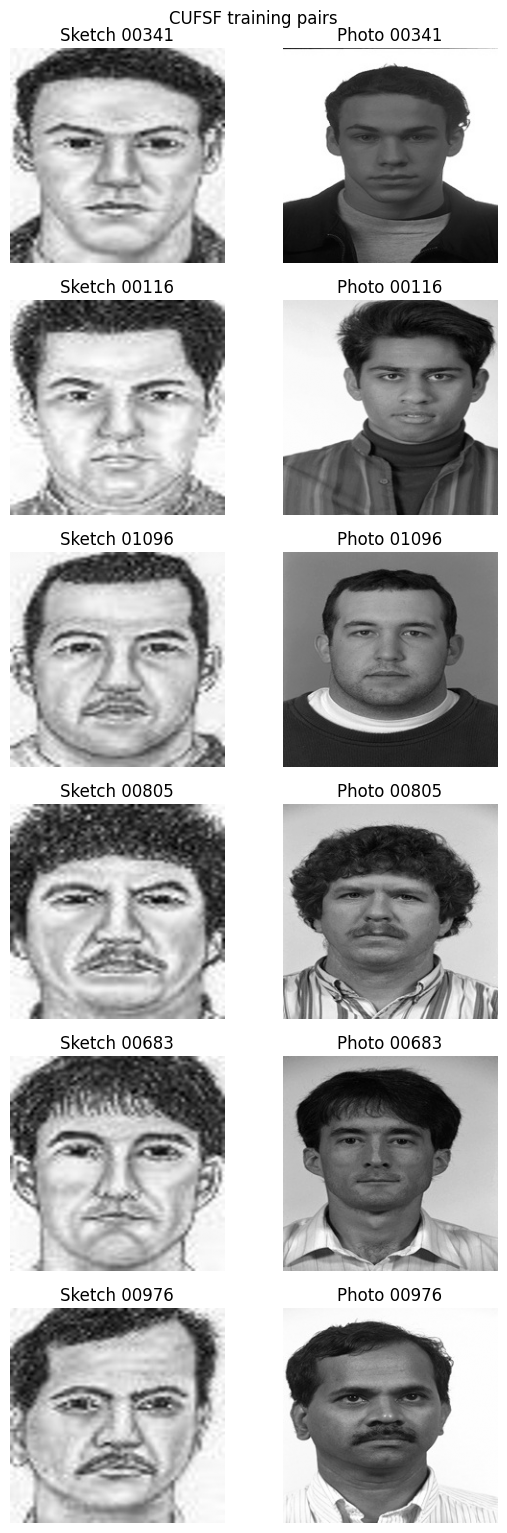

In [3]:
def show_random_pairs(df, n=6, seed=42, title='Random pairs'):
    sample = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(sample), 2, figsize=(6, 2.6 * len(sample)))
    if len(sample) == 1:
        axes = np.array([axes])

    for i, row in sample.iterrows():
        sketch = Image.open(row['sketch_path']).convert('L')
        photo = Image.open(row['photo_path']).convert('L')
        axes[i, 0].imshow(sketch, cmap='gray')
        axes[i, 0].set_title(f"Sketch {row['id']}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(photo, cmap='gray')
        axes[i, 1].set_title(f"Photo {row['id']}")
        axes[i, 1].axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_random_pairs(train_df, n=6, seed=SEED, title='CUFSF training pairs')

## 4. Dataset, transforms, and loaders

Each batch contains aligned sketch-photo pairs. The contrastive objective uses the other items in the batch as negatives.

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.15, contrast=0.15)
    ], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SketchPhotoPairDataset(Dataset):
    def __init__(self, pairs_df, transform):
        self.df = pairs_df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sketch = Image.open(row['sketch_path']).convert('RGB')
        photo = Image.open(row['photo_path']).convert('RGB')
        return {
            'id': str(row['id']),
            'sketch': self.transform(sketch),
            'photo': self.transform(photo),
            'sketch_path': row['sketch_path'],
            'photo_path': row['photo_path'],
        }

train_dataset = SketchPhotoPairDataset(train_df, train_transform)
val_dataset = SketchPhotoPairDataset(val_df, eval_transform)
test_dataset = SketchPhotoPairDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

batch = next(iter(train_loader))
print('Batch ids:', batch['id'][:5])
print('Sketch batch:', tuple(batch['sketch'].shape))
print('Photo batch:', tuple(batch['photo'].shape))

Batch ids: ['00471', '00256', '00196', '00263', '00112']
Sketch batch: (32, 3, 224, 224)
Photo batch: (32, 3, 224, 224)


## 5. Model and contrastive loss

The same encoder is used for sketches and photos so both domains are projected into one shared embedding space.

In [5]:
class ResNet18ProjectionEncoder(nn.Module):
    def __init__(self, projection_dim=128, pretrained=True):
        super().__init__()
        if pretrained:
            try:
                weights = models.ResNet18_Weights.DEFAULT
                backbone = models.resnet18(weights=weights)
                print('Loaded ImageNet pretrained ResNet18 weights.')
            except Exception as exc:
                print('Could not load pretrained weights; using random initialization.')
                print('Reason:', repr(exc))
                backbone = models.resnet18(weights=None)
        else:
            backbone = models.resnet18(weights=None)

        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.projection = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(inplace=True),
            nn.Linear(feature_dim, projection_dim),
        )

    def forward(self, x):
        features = self.backbone(x)
        projected = self.projection(features)
        return F.normalize(projected, p=2, dim=1)


def symmetric_contrastive_loss(sketch_embeddings, photo_embeddings, temperature=0.07):
    logits = sketch_embeddings @ photo_embeddings.T
    logits = logits / temperature
    targets = torch.arange(logits.size(0), device=logits.device)
    sketch_to_photo = F.cross_entropy(logits, targets)
    photo_to_sketch = F.cross_entropy(logits.T, targets)
    return (sketch_to_photo + photo_to_sketch) / 2

model = ResNet18ProjectionEncoder(projection_dim=PROJECTION_DIM, pretrained=True).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

with torch.no_grad():
    sample_sketch = batch['sketch'][:4].to(DEVICE)
    sample_photo = batch['photo'][:4].to(DEVICE)
    sketch_emb = model(sample_sketch)
    photo_emb = model(sample_photo)
    sample_loss = symmetric_contrastive_loss(sketch_emb, photo_emb, temperature=TEMPERATURE)

print('Embedding shape:', tuple(sketch_emb.shape))
print('Sample contrastive loss:', float(sample_loss.cpu()))

Loaded ImageNet pretrained ResNet18 weights.
Embedding shape: (4, 128)
Sample contrastive loss: 0.9305661916732788


## 6. Retrieval metrics and encoding helpers

Validation and test retrieval rank each sketch against every photo in that split.

In [6]:
def evaluate_similarity_matrix(similarity, query_ids, gallery_ids, ks=(1, 5, 10)):
    query_ids = list(query_ids)
    gallery_ids = list(gallery_ids)
    gallery_id_to_index = {gid: idx for idx, gid in enumerate(gallery_ids)}

    ranks = []
    for i, qid in enumerate(query_ids):
        if qid not in gallery_id_to_index:
            raise ValueError(f'Query id {qid} not found in gallery.')
        correct_idx = gallery_id_to_index[qid]
        ranked_indices = np.argsort(-similarity[i])
        rank = int(np.where(ranked_indices == correct_idx)[0][0]) + 1
        ranks.append(rank)

    ranks = np.array(ranks)
    metrics = {f'Recall@{k}': float(np.mean(ranks <= k)) for k in ks}
    metrics['MRR'] = float(np.mean(1.0 / ranks))
    metrics['MeanRank'] = float(np.mean(ranks))
    metrics['MedianRank'] = float(np.median(ranks))
    return metrics, ranks


def print_metrics(name, metrics):
    print(f'\n{name}')
    print('-' * len(name))
    for key, value in metrics.items():
        if key.startswith('Recall') or key == 'MRR':
            print(f'{key}: {value:.4f}')
        else:
            print(f'{key}: {value:.2f}')

@torch.no_grad()
def encode_pair_loader(model, loader, device):
    model.eval()
    sketch_embeddings = []
    photo_embeddings = []
    ids = []

    for batch in tqdm(loader, desc='Encoding retrieval split', leave=False):
        sketch = batch['sketch'].to(device, non_blocking=True)
        photo = batch['photo'].to(device, non_blocking=True)
        sketch_embeddings.append(model(sketch).cpu())
        photo_embeddings.append(model(photo).cpu())
        ids.extend([str(x) for x in batch['id']])

    sketch_embeddings = torch.cat(sketch_embeddings, dim=0).numpy()
    photo_embeddings = torch.cat(photo_embeddings, dim=0).numpy()
    return ids, sketch_embeddings, photo_embeddings


def evaluate_retrieval_split(model, loader, name, device=DEVICE, ks=(1, 5, 10)):
    ids, sketch_embeddings, photo_embeddings = encode_pair_loader(model, loader, device)
    similarity = sketch_embeddings @ photo_embeddings.T
    metrics, ranks = evaluate_similarity_matrix(similarity, ids, ids, ks=ks)
    print_metrics(name, metrics)
    return metrics, ranks, similarity, ids

## 7. Training loop

The best checkpoint is selected by validation `MRR` by default. Change `VAL_SELECTION_METRIC` in the config cell if you prefer `Recall@1`.

In [7]:
def train_one_epoch(model, loader, optimizer, device, temperature):
    model.train()
    losses = []

    for batch in tqdm(loader, desc='Training', leave=False):
        sketches = batch['sketch'].to(device, non_blocking=True)
        photos = batch['photo'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        sketch_embeddings = model(sketches)
        photo_embeddings = model(photos)
        loss = symmetric_contrastive_loss(sketch_embeddings, photo_embeddings, temperature=temperature)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))

    return float(np.mean(losses))

history = []
best_metric = -math.inf
best_epoch = -1
epochs_without_improvement = 0
best_model_path = MODEL_DIR / 'best_resnet18_contrastive.pt'
last_model_path = MODEL_DIR / 'last_resnet18_contrastive.pt'

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE, TEMPERATURE)
    val_metrics, val_ranks, val_similarity, val_ids = evaluate_retrieval_split(
        model, val_loader, name=f'Validation epoch {epoch}', device=DEVICE
    )
    scheduler.step()

    selected_metric = val_metrics[VAL_SELECTION_METRIC]
    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'lr': optimizer.param_groups[0]['lr'],
        'seconds': time.time() - epoch_start,
        **{f'val_{k}': v for k, v in val_metrics.items()},
    }
    history.append(row)

    improved = selected_metric > best_metric
    if improved:
        best_metric = selected_metric
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': {
                'image_size': IMAGE_SIZE,
                'batch_size': BATCH_SIZE,
                'epochs': EPOCHS,
                'learning_rate': LEARNING_RATE,
                'weight_decay': WEIGHT_DECAY,
                'projection_dim': PROJECTION_DIM,
                'temperature': TEMPERATURE,
                'val_selection_metric': VAL_SELECTION_METRIC,
                'seed': SEED,
            },
            'val_metrics': val_metrics,
        }, best_model_path)
        print(f'Saved new best checkpoint: {best_model_path}')
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | loss={train_loss:.4f} | "
        f"val_{VAL_SELECTION_METRIC}={selected_metric:.4f} | best_epoch={best_epoch} | "
        f"time={row['seconds']:.1f}s"
    )

    if epochs_without_improvement >= PATIENCE:
        print(f'Early stopping after {PATIENCE} epochs without validation improvement.')
        break

torch.save({'epoch': history[-1]['epoch'], 'model_state_dict': model.state_dict()}, last_model_path)
history_df = pd.DataFrame(history)
history_csv = OUTPUT_DIR / 'training_history.csv'
history_df.to_csv(history_csv, index=False)

print('\nTraining time minutes:', (time.time() - start_time) / 60)
print('Best epoch:', best_epoch)
print('Best validation metric:', best_metric)
print('Saved history:', history_csv)
display(history_df.tail())


Validation epoch 1
------------------
Recall@1: 0.0785
Recall@5: 0.2565
Recall@10: 0.3874
MRR: 0.1802
MeanRank: 26.27
MedianRank: 16.00
Saved new best checkpoint: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/models/best_resnet18_contrastive.pt
Epoch 001/20 | loss=2.3638 | val_MRR=0.1802 | best_epoch=1 | time=48.0s



Validation epoch 2
------------------
Recall@1: 0.1518
Recall@5: 0.4031
Recall@10: 0.5916
MRR: 0.2819
MeanRank: 13.90
MedianRank: 8.00
Saved new best checkpoint: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/models/best_resnet18_contrastive.pt
Epoch 002/20 | loss=0.7895 | val_MRR=0.2819 | best_epoch=2 | time=46.1s



Validation epoch 3
------------------
Recall@1: 0.1728
Recall@5: 0.4346
Recall@10: 0.6597
MRR: 0.3111
MeanRank: 13.40
MedianRank: 6.00
Saved new best checkpoint: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/models/best_resnet18_contrastive.pt
Epoch 003/20 | loss=0.2916 | val_MRR=0.3111 | best_epoch=3 | time=56.3s



Validation epoch 4
------------------
Recall@1: 0.2251
Recall@5: 0.5131
Recall@10: 0.7068
MRR: 0.3653
MeanRank: 11.19
MedianRank: 5.00
Saved new best checkpoint: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/models/best_resnet18_contrastive.pt
Epoch 004/20 | loss=0.1528 | val_MRR=0.3653 | best_epoch=4 | time=54.0s



Validation epoch 5
------------------
Recall@1: 0.2199
Recall@5: 0.5654
Recall@10: 0.7382
MRR: 0.3792
MeanRank: 10.05
MedianRank: 4.00
Saved new best checkpoint: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/models/best_resnet18_contrastive.pt
Epoch 005/20 | loss=0.1096 | val_MRR=0.3792 | best_epoch=5 | time=56.1s


...


Validation epoch 12
-------------------
Recall@1: 0.2356
Recall@5: 0.5759
Recall@10: 0.7277
MRR: 0.3977
MeanRank: 9.87
MedianRank: 4.00
Epoch 012/20 | loss=0.0300 | val_MRR=0.3977 | best_epoch=7 | time=51.9s



Validation epoch 13
-------------------
Recall@1: 0.2408
Recall@5: 0.5812
Recall@10: 0.7225
MRR: 0.3952
MeanRank: 10.45
MedianRank: 4.00
Epoch 013/20 | loss=0.0285 | val_MRR=0.3952 | best_epoch=7 | time=54.3s



Validation epoch 14
-------------------
Recall@1: 0.2670
Recall@5: 0.5864
Recall@10: 0.7382
MRR: 0.4158
MeanRank: 10.18
MedianRank: 4.00
Epoch 014/20 | loss=0.0237 | val_MRR=0.4158 | best_epoch=7 | time=43.5s



Validation epoch 15
-------------------
Recall@1: 0.2513
Recall@5: 0.5707
Recall@10: 0.7382
MRR: 0.4029
MeanRank: 10.69
MedianRank: 4.00
Epoch 015/20 | loss=0.0250 | val_MRR=0.4029 | best_epoch=7 | time=42.8s
Early stopping after 8 epochs without validation improvement.

Training time minutes: 12.93931048711141
Best epoch: 7
Best validation metric: 0.4209715054055163
Saved history: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/training_history.csv


,epoch,train_loss,lr,seconds,val_Recall@1,val_Recall@5,val_Recall@10,val_MRR,val_MeanRank,val_MedianRank
10,11,0.031559,0.000042,54.617145,0.225131,0.544503,0.691099,0.380831,10.518325,5.0
11,12,0.030030,0.000035,51.920124,0.235602,0.575916,0.727749,0.397741,9.874346,4.0
12,13,0.028532,0.000027,54.270025,0.240838,0.581152,0.722513,0.395157,10.450262,4.0
13,14,0.023675,0.000021,43.515164,0.267016,0.586387,0.738220,0.415818,10.183246,4.0
14,15,0.025045,0.000015,42.793250,0.251309,0.570681,0.738220,0.402863,10.685864,4.0


## 8. Curves

These figures are saved for the final report.

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/figures/training_curves.png


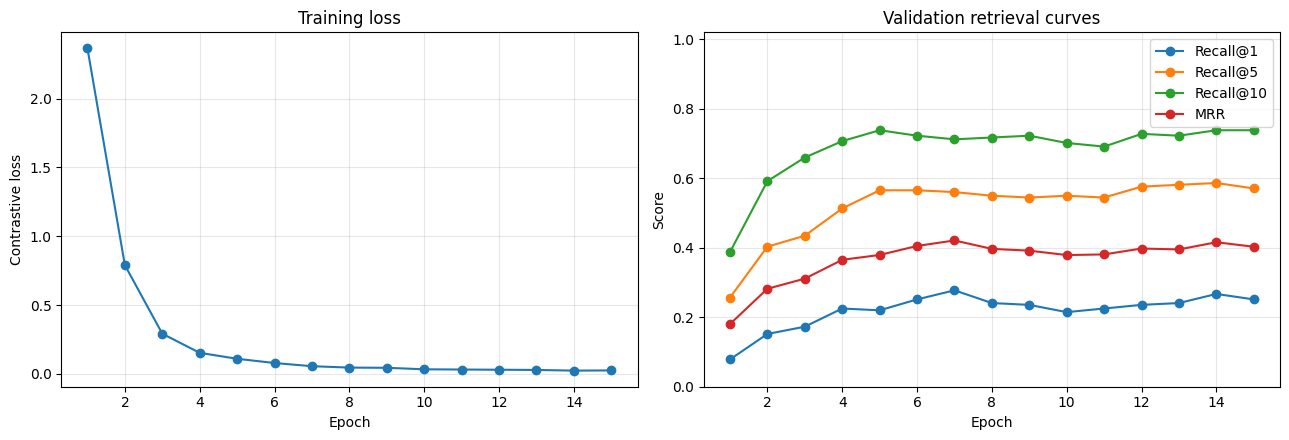

In [8]:
def plot_training_curves(history_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Contrastive loss')
    axes[0].set_title('Training loss')
    axes[0].grid(True, alpha=0.3)

    for metric in ['val_Recall@1', 'val_Recall@5', 'val_Recall@10', 'val_MRR']:
        if metric in history_df.columns:
            axes[1].plot(history_df['epoch'], history_df[metric], marker='o', label=metric.replace('val_', ''))
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1.02)
    axes[1].set_title('Validation retrieval curves')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    curve_path = FIGURE_DIR / 'training_curves.png'
    fig.savefig(curve_path, dpi=150, bbox_inches='tight')
    print('Saved:', curve_path)
    plt.show()

plot_training_curves(history_df)

## 9. Final CUFSF test evaluation

This cell reloads the best validation checkpoint before evaluating on the frozen test split.

In [9]:
def load_checkpoint_for_eval(path, projection_dim=PROJECTION_DIM, device=DEVICE):
    eval_model = ResNet18ProjectionEncoder(projection_dim=projection_dim, pretrained=False).to(device)
    checkpoint = torch.load(path, map_location=device)
    eval_model.load_state_dict(checkpoint['model_state_dict'])
    eval_model.eval()
    print('Loaded checkpoint:', path)
    print('Checkpoint epoch:', checkpoint.get('epoch'))
    return eval_model, checkpoint

best_model, best_checkpoint = load_checkpoint_for_eval(best_model_path)

test_metrics, test_ranks, test_similarity, test_ids = evaluate_retrieval_split(
    best_model,
    test_loader,
    name='Fine-tuned ResNet18 CUFSF test',
    device=DEVICE,
)

results = pd.DataFrame([
    {'split': 'val', 'method': 'Fine-tuned ResNet18', **best_checkpoint.get('val_metrics', {})},
    {'split': 'test', 'method': 'Fine-tuned ResNet18', **test_metrics},
])
results_csv = OUTPUT_DIR / 'fine_tuned_results.csv'
results.to_csv(results_csv, index=False)
print('Saved:', results_csv)
display(results)

Loaded checkpoint: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/models/best_resnet18_contrastive.pt
Checkpoint epoch: 7



Fine-tuned ResNet18 CUFSF test
------------------------------
Recall@1: 0.2720
Recall@5: 0.5649
Recall@10: 0.6778
MRR: 0.4061
MeanRank: 11.49
MedianRank: 4.00
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/fine_tuned_results.csv


,split,method,Recall@1,Recall@5,Recall@10,MRR,MeanRank,MedianRank
0,val,Fine-tuned ResNet18,0.277487,0.560209,0.712042,0.420972,9.78534,4.0
1,test,Fine-tuned ResNet18,0.271967,0.564854,0.677824,0.406139,11.48954,4.0


## 10. Top-5 retrieval visualizations

Each row shows the query sketch, the correct photo, and the top-5 retrieved photos.

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/retrieval_examples/fine_tuned_cufsf_test_top5.png


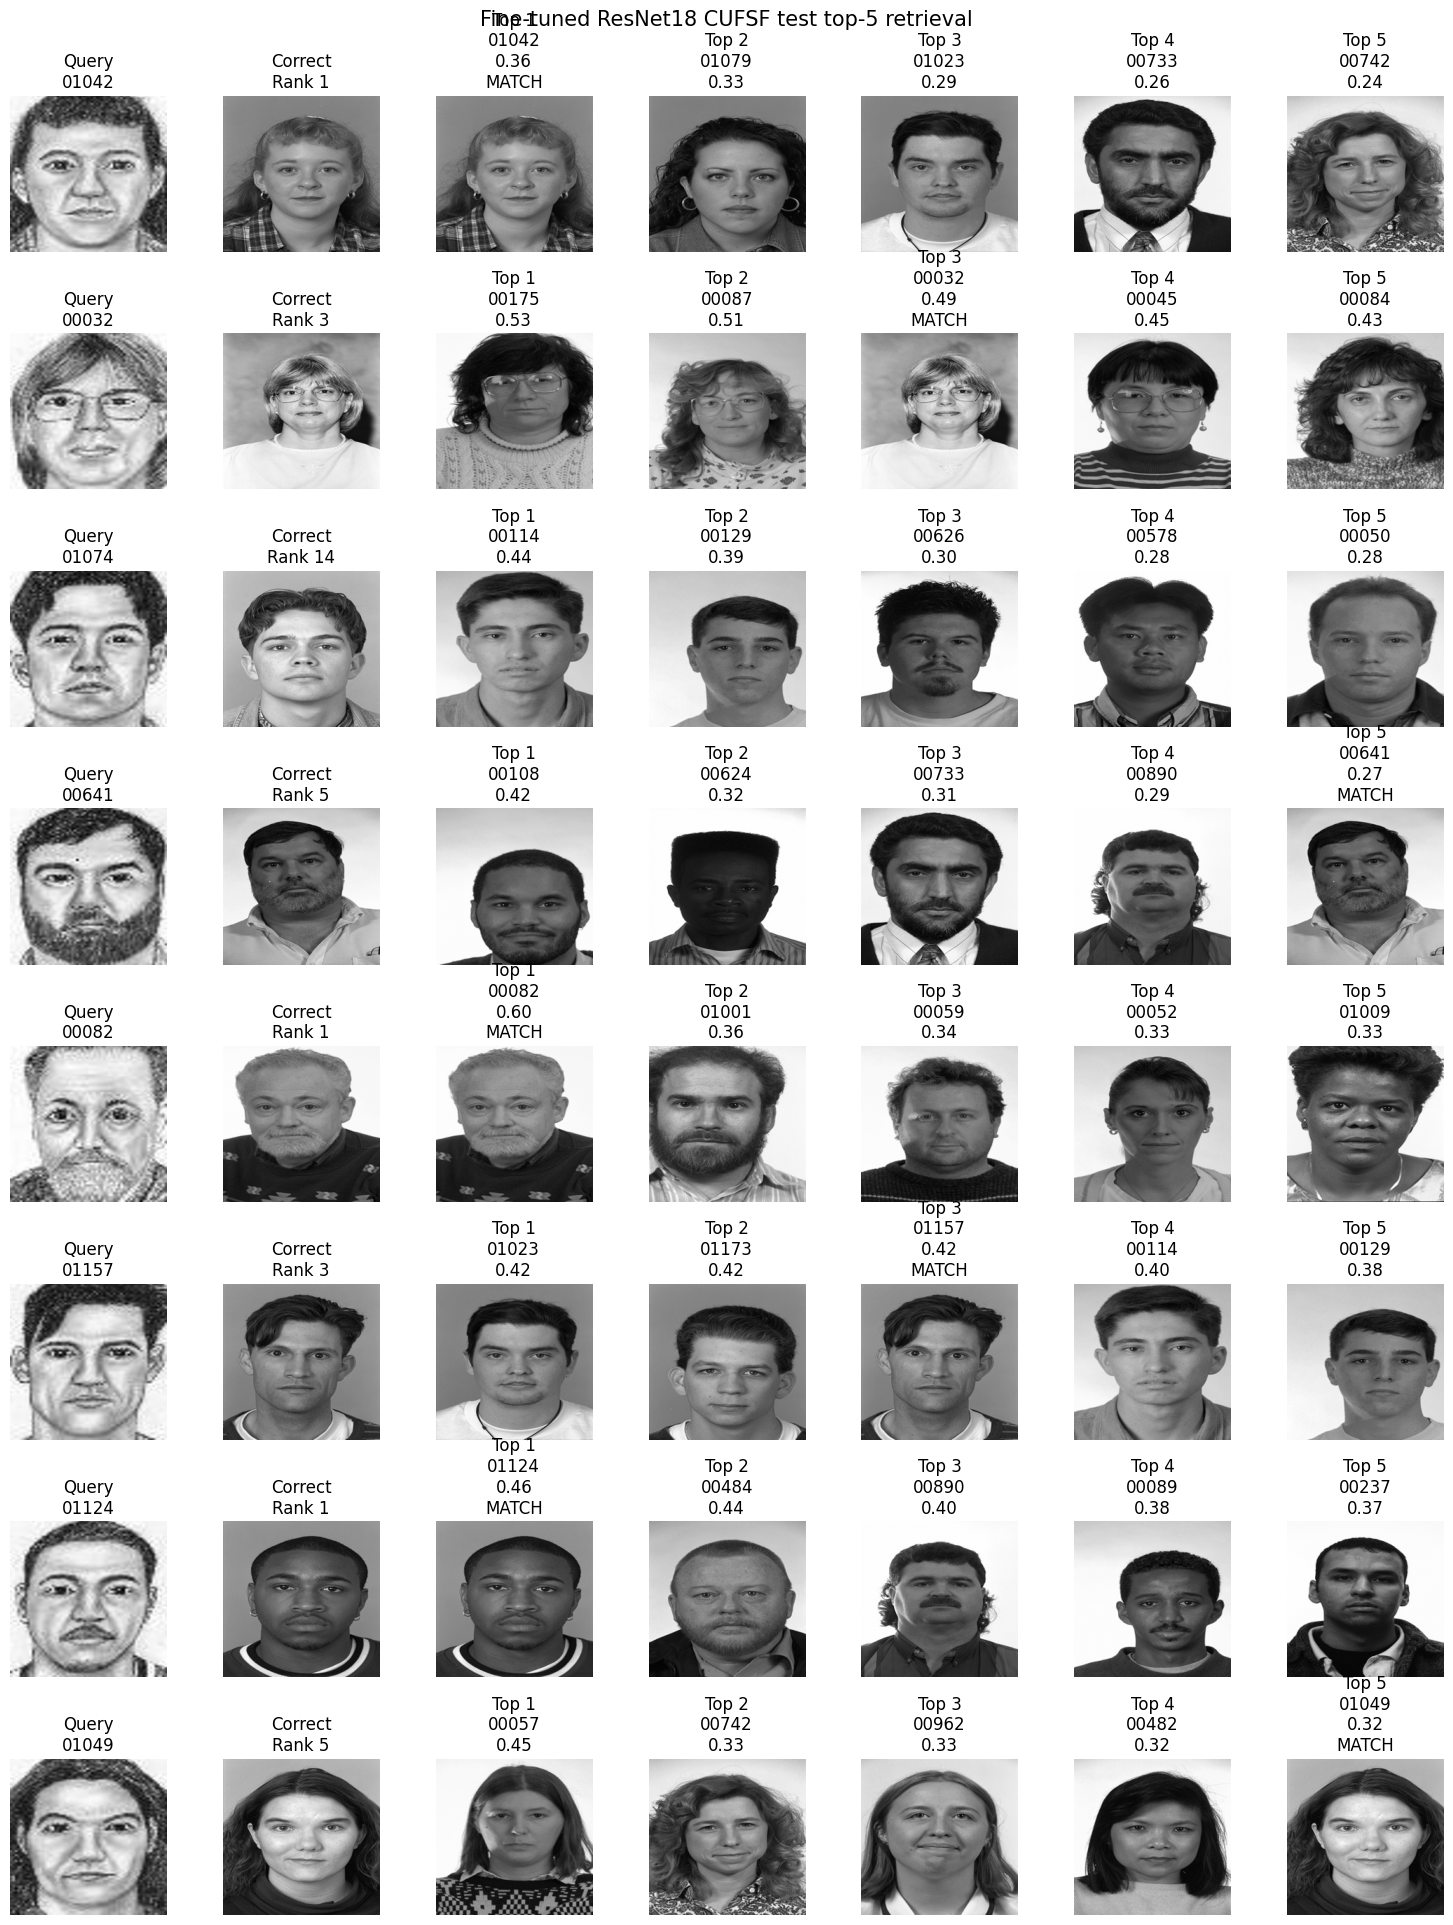

In [10]:
def make_retrieval_grid(df, similarity, ranks, method_name, n_examples=8, top_k=5, seed=42, save_path=None):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(df), size=min(n_examples, len(df)), replace=False)

    num_cols = 2 + top_k
    fig, axes = plt.subplots(len(indices), num_cols, figsize=(2.15 * num_cols, 2.45 * len(indices)))
    if len(indices) == 1:
        axes = np.array([axes])

    for row_i, query_idx in enumerate(indices):
        query = df.iloc[query_idx]
        ranked = np.argsort(-similarity[query_idx])[:top_k]

        sketch = Image.open(query['sketch_path']).convert('L')
        correct = Image.open(query['photo_path']).convert('L')

        axes[row_i, 0].imshow(sketch, cmap='gray')
        axes[row_i, 0].set_title(f"Query\n{query['id']}")
        axes[row_i, 0].axis('off')

        axes[row_i, 1].imshow(correct, cmap='gray')
        axes[row_i, 1].set_title(f"Correct\nRank {ranks[query_idx]}")
        axes[row_i, 1].axis('off')

        for j, gallery_idx in enumerate(ranked):
            item = df.iloc[gallery_idx]
            img = Image.open(item['photo_path']).convert('L')
            is_correct = str(item['id']) == str(query['id'])
            score = similarity[query_idx, gallery_idx]
            title = f"Top {j + 1}\n{item['id']}\n{score:.2f}"
            if is_correct:
                title += '\nMATCH'
            axes[row_i, 2 + j].imshow(img, cmap='gray')
            axes[row_i, 2 + j].set_title(title)
            axes[row_i, 2 + j].axis('off')

    fig.suptitle(method_name, fontsize=15)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print('Saved:', save_path)
    plt.show()

make_retrieval_grid(
    test_df,
    test_similarity,
    test_ranks,
    method_name='Fine-tuned ResNet18 CUFSF test top-5 retrieval',
    n_examples=8,
    top_k=5,
    seed=SEED,
    save_path=RETRIEVAL_DIR / 'fine_tuned_cufsf_test_top5.png',
)

## 11. Optional FS2K OOD pair building

FS2K is stored as three matching folder groups:

```text
photo/photo1/image0001.jpg  <->  sketch/sketch1/sketch0001.jpg
photo/photo2/image0001.jpg  <->  sketch/sketch2/sketch0001.png
photo/photo3/image0001.jpg  <->  sketch/sketch3/sketch0001.jpg
```

This cell builds a folder-aware `fs2k_pairs.csv` and audits the mapping.

Group 1: photos=1529, sketches=1529, pairs=1529
Group 2: photos=98, sketches=98, pairs=98
Group 3: photos=477, sketches=477, pairs=477
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/splits/fs2k_pairs.csv
[FS2K OOD] rows: 2104
[FS2K OOD] unique ids: 2104
[FS2K OOD] sketches exist: 2104 / 2104
[FS2K OOD] photos exist: 2104 / 2104
[FS2K OOD] duplicate ids: 0
FS2K pairs: 2104


,id,dataset,group,sketch_path,photo_path
0,fs2k_1_0001,FS2K,1,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...
1,fs2k_1_0002,FS2K,1,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...
2,fs2k_1_0003,FS2K,1,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...
3,fs2k_1_0004,FS2K,1,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...
4,fs2k_1_0005,FS2K,1,/home/tndor/Documents/Work/Classwork/semester-...,/home/tndor/Documents/Work/Classwork/semester-...


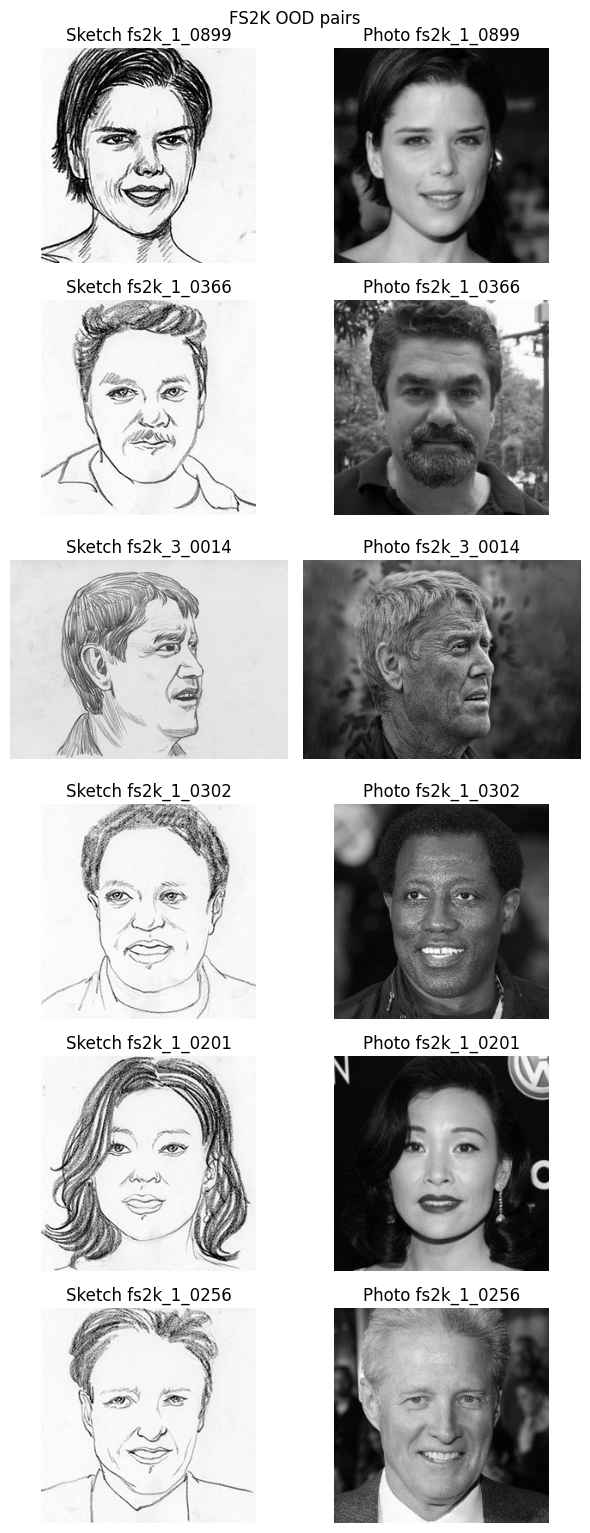

In [11]:
def numeric_stem(path):
    match = re.search(r'(\d+)', Path(path).stem)
    return match.group(1) if match else None


def build_fs2k_pairs(fs2k_dir, save_csv):
    rows = []
    for group_idx in [1, 2, 3]:
        photo_dir = fs2k_dir / 'photo' / f'photo{group_idx}'
        sketch_dir = fs2k_dir / 'sketch' / f'sketch{group_idx}'
        if not photo_dir.exists() or not sketch_dir.exists():
            print('Skipping missing FS2K group:', group_idx)
            continue

        photos = {}
        for path in photo_dir.iterdir():
            if path.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                key = numeric_stem(path)
                if key is not None:
                    photos[key] = path

        sketches = {}
        for path in sketch_dir.iterdir():
            if path.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
                key = numeric_stem(path)
                if key is not None:
                    sketches[key] = path

        for key in sorted(set(photos) & set(sketches)):
            rows.append({
                'id': f'fs2k_{group_idx}_{key}',
                'dataset': 'FS2K',
                'group': group_idx,
                'sketch_path': str(sketches[key]),
                'photo_path': str(photos[key]),
            })

        print(f'Group {group_idx}: photos={len(photos)}, sketches={len(sketches)}, pairs={len(set(photos) & set(sketches))}')

    fs2k_df = pd.DataFrame(rows).sort_values('id').reset_index(drop=True)
    fs2k_df.to_csv(save_csv, index=False)
    print('Saved:', save_csv)
    return fs2k_df

if FS2K_PAIRS_CSV.exists():
    fs2k_df = pd.read_csv(FS2K_PAIRS_CSV, dtype={'id': str})
    print('Loaded existing FS2K pairs:', FS2K_PAIRS_CSV)
else:
    fs2k_df = build_fs2k_pairs(FS2K_DIR, FS2K_PAIRS_CSV)

fs2k_df = audit_pairs(fs2k_df, 'FS2K OOD')
print('FS2K pairs:', len(fs2k_df))
display(fs2k_df.head())
show_random_pairs(fs2k_df, n=6, seed=SEED, title='FS2K OOD pairs')

## 12. Optional FS2K OOD retrieval evaluation

This evaluates the CUFSF-trained checkpoint on FS2K without fine-tuning on FS2K.


Fine-tuned ResNet18 FS2K OOD
----------------------------
Recall@1: 0.0043
Recall@5: 0.0147
Recall@10: 0.0214
MRR: 0.0132
MeanRank: 850.17
MedianRank: 767.00
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/cufsf_test_vs_fs2k_ood_results.csv


,split,method,Recall@1,Recall@5,Recall@10,MRR,MeanRank,MedianRank
0,CUFSF test,Fine-tuned ResNet18,0.271967,0.564854,0.677824,0.406139,11.489540,4.0
1,FS2K OOD,Fine-tuned ResNet18,0.004278,0.014734,0.021388,0.013157,850.171578,767.0


Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/retrieval_examples/fine_tuned_fs2k_ood_top5.png


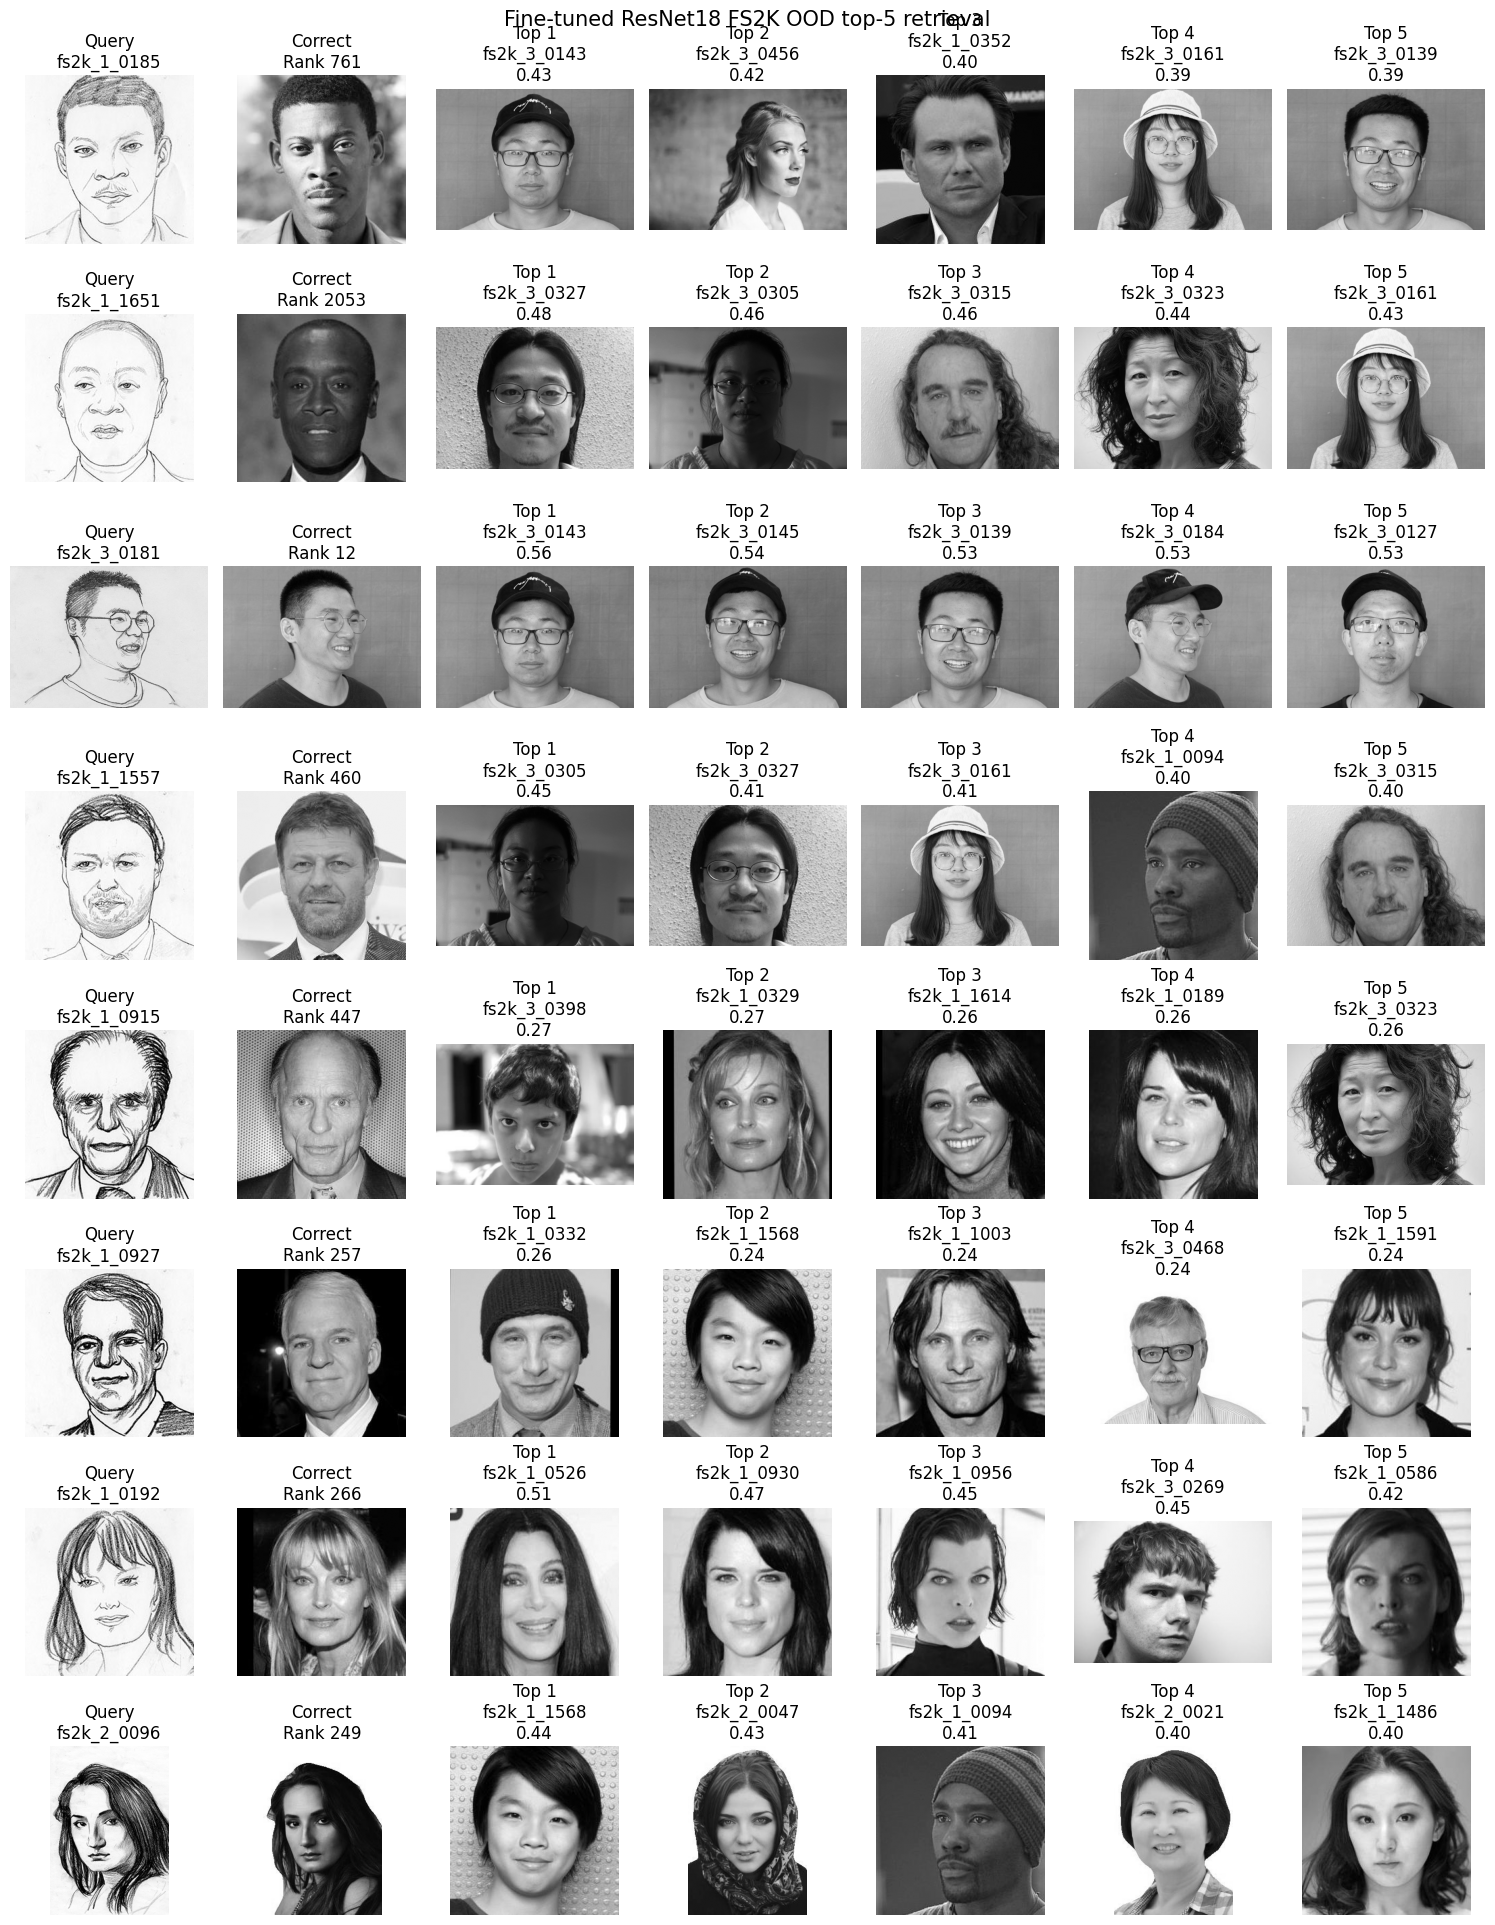

In [12]:
fs2k_dataset = SketchPhotoPairDataset(fs2k_df, eval_transform)
fs2k_loader = DataLoader(
    fs2k_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

fs2k_metrics, fs2k_ranks, fs2k_similarity, fs2k_ids = evaluate_retrieval_split(
    best_model,
    fs2k_loader,
    name='Fine-tuned ResNet18 FS2K OOD',
    device=DEVICE,
)

ood_results = pd.DataFrame([
    {'split': 'CUFSF test', 'method': 'Fine-tuned ResNet18', **test_metrics},
    {'split': 'FS2K OOD', 'method': 'Fine-tuned ResNet18', **fs2k_metrics},
])
ood_results_csv = OUTPUT_DIR / 'cufsf_test_vs_fs2k_ood_results.csv'
ood_results.to_csv(ood_results_csv, index=False)
print('Saved:', ood_results_csv)
display(ood_results)

make_retrieval_grid(
    fs2k_df,
    fs2k_similarity,
    fs2k_ranks,
    method_name='Fine-tuned ResNet18 FS2K OOD top-5 retrieval',
    n_examples=8,
    top_k=5,
    seed=SEED,
    save_path=RETRIEVAL_DIR / 'fine_tuned_fs2k_ood_top5.png',
)

## 13. Notes for reporting

Useful files produced by this notebook:

```text
data/outputs/contrastive_resnet18_cufsf/splits/train_pairs.csv
data/outputs/contrastive_resnet18_cufsf/splits/val_pairs.csv
data/outputs/contrastive_resnet18_cufsf/splits/test_pairs.csv
data/outputs/contrastive_resnet18_cufsf/models/best_resnet18_contrastive.pt
data/outputs/contrastive_resnet18_cufsf/training_history.csv
data/outputs/contrastive_resnet18_cufsf/fine_tuned_results.csv
data/outputs/contrastive_resnet18_cufsf/cufsf_test_vs_fs2k_ood_results.csv
data/outputs/contrastive_resnet18_cufsf/figures/training_curves.png
data/outputs/contrastive_resnet18_cufsf/retrieval_examples/fine_tuned_cufsf_test_top5.png
data/outputs/contrastive_resnet18_cufsf/retrieval_examples/fine_tuned_fs2k_ood_top5.png
```

For the first serious run, try the default `EPOCHS = 20`. If validation keeps improving, increase to 50 or 100 and rerun from the top after deleting only the model/history outputs, not the split CSVs.